# **Klasifikasi Penyakit Kulit pada Kucing Menggunakan Arsitektur ResNet50 Berbasis Transfer Learning**


# **1. Persiapan Dataset**


## **1.1. Import Library**


In [1]:
!pip install -q split-folders

import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders

from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **1.2. Menghubungkan Google Colab dengan Google Drive**


In [3]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## **1.3. Konfigurasi Path Dataset**


In [4]:
dataset_path = "/content/drive/MyDrive/Skripsi/dataset_mix_marsa_50422863"
classes = ["FAD", "ringworm", "scabies"]

print("Path dataset:", dataset_path)
print("Kelas:", classes)


Path dataset: /content/drive/MyDrive/Skripsi/dataset_mix_marsa_50422863
Kelas: ['FAD', 'ringworm', 'scabies']


## **1.4. Menampilkan Jumlah Dataset**


In [5]:
jumlah_dataset = {
    kelas: len(glob.glob(os.path.join(dataset_path, kelas, "*")))
    for kelas in classes
}

print("Total keseluruhan :", sum(jumlah_dataset.values()))
print("FAD               :", jumlah_dataset["FAD"])
print("Ringworm          :", jumlah_dataset["ringworm"])
print("Scabies           :", jumlah_dataset["scabies"])

Total keseluruhan : 336
FAD               : 115
Ringworm          : 110
Scabies           : 111


# **2. Preprocessing Data**


## **2.1. Resize**


In [6]:
IMAGE_SIZE = (224, 224)
resize_folder = "/content/drive/MyDrive/Skripsi/Dataset_Resize"
os.makedirs(resize_folder, exist_ok=True)

for kelas in classes:
    output_folder = os.path.join(resize_folder, kelas)
    os.makedirs(output_folder, exist_ok=True)

    for img_path in glob.glob(os.path.join(dataset_path, kelas, "*")):
        image = Image.open(img_path).convert("RGB")
        image = image.resize(IMAGE_SIZE)
        image.save(os.path.join(output_folder, os.path.basename(img_path)))


## **2.2. Reformat ke PNG**


In [7]:
png_folder = "/content/drive/MyDrive/Skripsi/Dataset_PNG"
os.makedirs(png_folder, exist_ok=True)

for kelas in classes:
    output_folder = os.path.join(png_folder, kelas)
    os.makedirs(output_folder, exist_ok=True)

    for img_path in glob.glob(os.path.join(resize_folder, kelas, "*")):
        image = Image.open(img_path).convert("RGB")
        filename = os.path.splitext(os.path.basename(img_path))[0] + ".png"
        image.save(os.path.join(output_folder, filename), format="PNG")


## **2.3. Pembagian Dataset**


In [8]:
split_folder = "/content/drive/MyDrive/Skripsi/Dataset_Split_ResNet50"

splitfolders.ratio(
    png_folder,
    output=split_folder,
    seed=SEED,
    ratio=(0.8, 0.1, 0.1)
)

train_path = os.path.join(split_folder, "train")
valid_path = os.path.join(split_folder, "val")
test_path = os.path.join(split_folder, "test")

for folder_name, folder_path in {
    "Train": train_path,
    "Validation": valid_path,
    "Test": test_path
}.items():
    print(f"\n{folder_name}")
    for kelas in classes:
        print(kelas, ":", len(os.listdir(os.path.join(folder_path, kelas))))


Copying files: 336 files [00:04, 83.02 files/s]


Train
FAD : 92
ringworm : 88
scabies : 88

Validation
FAD : 11
ringworm : 11
scabies : 11

Test
FAD : 12
ringworm : 11
scabies : 12


## **2.4. Konfigurasi Augmentasi Data Training**


In [15]:
augmentation_config = {
    "rotation_range": 20,
    "zoom_range": 0.2,
    "horizontal_flip": True,
    "width_shift_range": 0.1,
    "height_shift_range": 0.1,
    "shear_range": 10,
    "brightness_range": [0.8, 1.2],
    "fill_mode": "nearest"
}

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    **augmentation_config
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


## **2.5. Visualisasi Sebelum dan Sesudah Setiap Augmentasi**


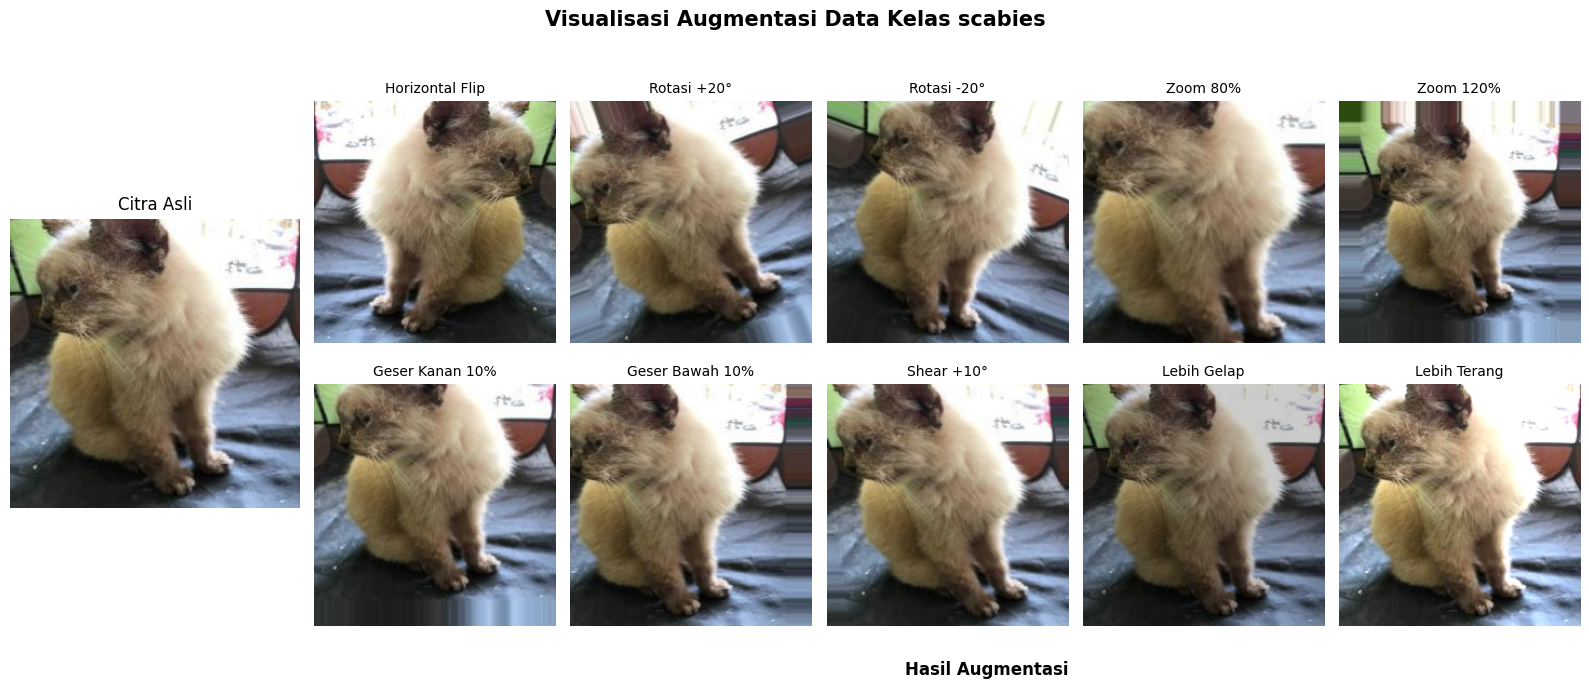

In [17]:
sample_class = random.choice(classes)

sample_path = os.path.join(
    train_path,
    sample_class,
    random.choice(os.listdir(os.path.join(train_path, sample_class)))
)

original_image = img_to_array(
    load_img(sample_path, target_size=IMAGE_SIZE)
)

visual_datagen = ImageDataGenerator(
    fill_mode="nearest"
)

visualizations = {
    "Horizontal Flip": {
        "flip_horizontal": True
    },
    "Rotasi +20°": {
        "theta": 20
    },
    "Rotasi -20°": {
        "theta": -20
    },
    "Zoom 80%": {
        "zx": 0.8,
        "zy": 0.8
    },
    "Zoom 120%": {
        "zx": 1.2,
        "zy": 1.2
    },
    "Geser Kanan 10%": {
        "ty": 0.1 * IMAGE_SIZE[1]
    },
    "Geser Bawah 10%": {
        "tx": 0.1 * IMAGE_SIZE[0]
    },
    "Shear +10°": {
        "shear": 10
    },
    "Lebih Gelap": {
        "brightness": 0.8
    },
    "Lebih Terang": {
        "brightness": 1.2
    }
}

fig = plt.figure(figsize=(16, 7))

grid = fig.add_gridspec(
    2,
    6,
    width_ratios=[1.2, 1, 1, 1, 1, 1]
)

# Citra asli di sebelah kiri
ax_original = fig.add_subplot(grid[:, 0])
ax_original.imshow(original_image.astype("uint8"))
ax_original.set_title("Citra Asli", fontsize=12)
ax_original.axis("off")

# Hasil augmentasi di sebelah kanan
for index, (nama, parameter) in enumerate(visualizations.items()):
    baris = index // 5
    kolom = (index % 5) + 1

    augmented_image = visual_datagen.apply_transform(
        original_image.copy(),
        parameter
    )

    ax = fig.add_subplot(grid[baris, kolom])
    ax.imshow(
        np.clip(augmented_image, 0, 255).astype("uint8")
    )
    ax.set_title(nama, fontsize=10)
    ax.axis("off")

fig.suptitle(
    f"Visualisasi Augmentasi Data Kelas {sample_class}",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.62,
    0.03,
    "Hasil Augmentasi",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0.06, 1, 0.94])
plt.show()

## **2.6. Pembuatan Generator Data**


In [18]:
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_directory(
    valid_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 268 images belonging to 3 classes.
Found 33 images belonging to 3 classes.
Found 35 images belonging to 3 classes.


## **2.7. Pemeriksaan One-Hot Encoding Label Kelas**


In [19]:
images, labels = next(train_generator)

print("Indeks kelas:", train_generator.class_indices)
print("Bentuk label:", labels.shape)
print("Contoh label one-hot:", labels[0])

train_generator.reset()


Indeks kelas: {'FAD': 0, 'ringworm': 1, 'scabies': 2}
Bentuk label: (32, 3)
Contoh label one-hot: [0. 1. 0.]


# **3. Perancangan Model ResNet50 Berbasis Transfer Learning**


## **3.1. Membuat Model ResNet50**


In [20]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(len(classes), activation="softmax")(x)

model_resnet50 = Model(inputs=base_model.input, outputs=output)
model_resnet50.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,563 (91.01 MB)

 Trainable params: 266,755 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

# **4. Training dan Validasi Model ResNet50**


## **4.1. Hyperparameter dan Callback**


In [21]:
LEARNING_RATE = 0.001
EPOCHS = 50

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "/content/ResNet50_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


## **4.2. Perhitungan Class Weight**


In [22]:
class_labels = np.unique(train_generator.classes)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=train_generator.classes
)
class_weights = dict(zip(class_labels, class_weights_array))

print("Class weight:", class_weights)


Class weight: {np.int32(0): np.float64(0.9710144927536232), np.int32(1): np.float64(1.0151515151515151), np.int32(2): np.float64(1.0151515151515151)}


## **4.3. Compile dan Training Model**


In [23]:
model_resnet50.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_resnet50 = model_resnet50.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4133 - loss: 1.6166
Epoch 1: val_accuracy improved from None to 0.72727, saving model to /content/ResNet50_best.keras

Epoch 1: finished saving model to /content/ResNet50_best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5410 - loss: 1.3473 - val_accuracy: 0.7273 - val_loss: 0.6756 - learning_rate: 0.0010
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.8011 - loss: 0.6768
Epoch 2: val_accuracy improved from 0.72727 to 0.81818, saving model to /content/ResNet50_best.keras

Epoch 2: finished saving model to /content/ResNet50_best.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 832ms/step - accuracy: 0.8396 - loss: 0.5064 - val_accuracy: 0.8182 - val_loss: 0.4079 - learning_rate: 0.0010
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.8281 - loss: 0.4386
Epoch 3: val_accuracy improved from 0.81818 to 0.84848, saving model to /content/ResNet50_best.keras

Epoch 3: finished saving model to /content/Res

## **4.4. Visualisasi Accuracy dan Loss**


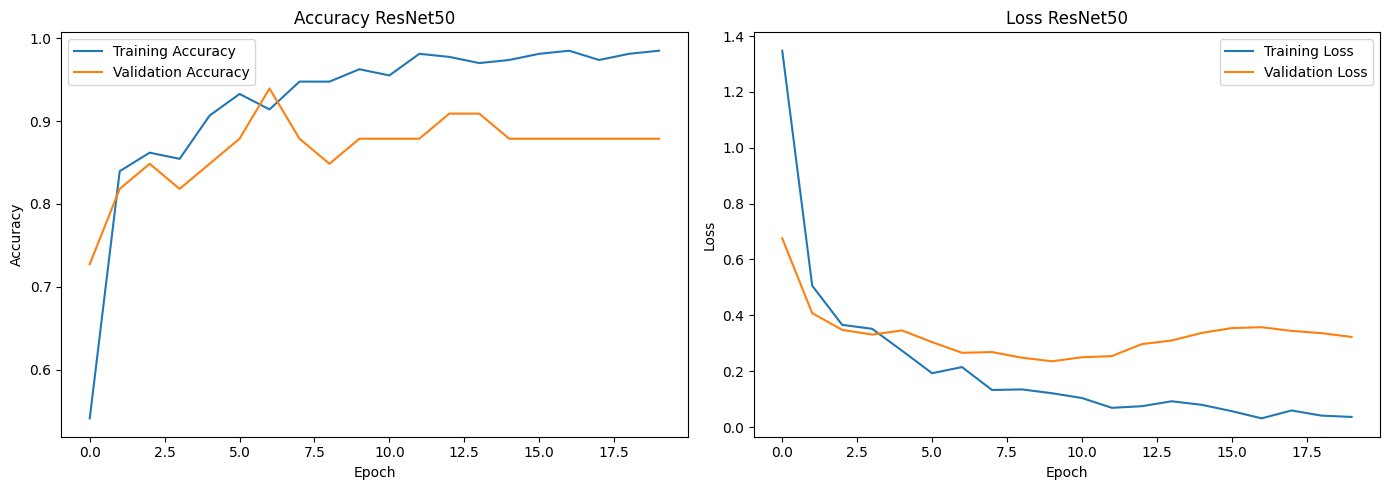

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_resnet50.history["accuracy"], label="Training Accuracy")
plt.plot(history_resnet50.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy ResNet50")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet50.history["loss"], label="Training Loss")
plt.plot(history_resnet50.history["val_loss"], label="Validation Loss")
plt.title("Loss ResNet50")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# **5. Evaluasi Model ResNet50**


## **5.1. Accuracy, Precision, Recall, dan F1-Score**


In [25]:
model_resnet50 = load_model("/content/ResNet50_best.keras")

test_generator.reset()
probabilities = model_resnet50.predict(test_generator, verbose=1)
y_pred = np.argmax(probabilities, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

hasil_evaluasi = pd.DataFrame([{
    "Model": "ResNet50",
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
}])

display(hasil_evaluasi.round(4))


2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step


,Model,Accuracy,Precision,Recall,F1-Score
0,ResNet50,0.8857,0.9143,0.8857,0.8812


## **5.2. Classification Report**


In [26]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
))


              precision    recall  f1-score   support

         FAD     0.7500    1.0000    0.8571        12
    ringworm     1.0000    0.6364    0.7778        11
     scabies     1.0000    1.0000    1.0000        12

    accuracy                         0.8857        35
   macro avg     0.9167    0.8788    0.8783        35
weighted avg     0.9143    0.8857    0.8812        35



## **5.3. Confusion Matrix**


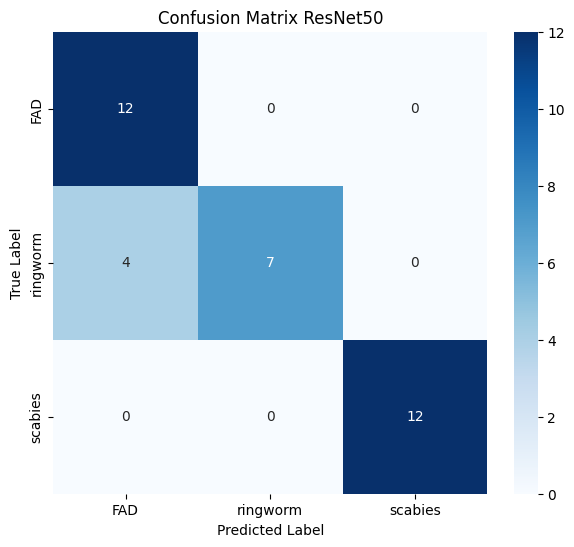

In [27]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix ResNet50")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# **6. Penyimpanan Model ResNet50**


In [28]:
model_resnet50.save("/content/drive/MyDrive/Skripsi/ResNet50_Penyakit_Kulit_Kucing.keras")
